# Notebook 03 — NDFD Forecast Integration

**Week 3 deliverable.** Connects the 7-day NOAA NDFD forecast to the burn window climatology from Week 2.

Answers the question a burn coordinator actually asks:
> *"Which stations have viable windows in the next 7 days, and is that window typical or unusual for this time of year?"

## Pipeline
```
ndfd_ingest.py          → data/processed/ndfd/forecast_parsed.csv
forecast_windows.py     → data/processed/ndfd/forecast_summary.csv
climatology_monthly.csv → anomaly baseline
```

## Outputs
1. **7-day forecast burn window table** — stations × days, color-coded by window quality tier
2. **Anomaly chart** — forecast viable hrs vs. climatological mean per station
3. **Findings summary** — auto-generated text from computed tables

In [1]:
import sys
from pathlib import Path

# Add repo root to path so src modules resolve
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore")

print(f"Repo root: {REPO_ROOT}")

Repo root: /home/carver-rasmussen/USDA-FS Project/notebooks


## 1. Run the forecast pipeline

Pulls NDFD for all 15 stations (cached per day — re-runs don't re-download),
applies threshold logic, and compares to climatological baseline.

In [3]:
import os
os.chdir("/home/carver-rasmussen/USDA-FS Project")  # set to your actual repo root
from src.ingest.ndfd_ingest import fetch_station_forecasts, load_stations
from src.analysis.forecast_windows import (
    apply_thresholds_to_forecast,
    daily_forecast_windows,
    forecast_summary_table,
    load_climatology_monthly,
    load_forecast_summary,
)

FORECAST_SUMMARY_PATH = Path("data/processed/ndfd/forecast_summary.csv")
FORCE_RERUN = False  # Set True to re-pull NDFD and recompute

if FORECAST_SUMMARY_PATH.exists() and not FORCE_RERUN:
    print("Loading cached forecast summary...")
    summary = load_forecast_summary()
else:
    print("Running full forecast pipeline...")
    stations = load_stations()
    forecast_raw = fetch_station_forecasts(stations)

    climo = load_climatology_monthly()
    flagged = apply_thresholds_to_forecast(forecast_raw)
    daily = daily_forecast_windows(flagged)
    summary = forecast_summary_table(daily, climo)

print(f"\nForecast summary: {len(summary)} rows, {summary['station_id'].nunique()} stations")
print(f"Date range: {summary['forecast_date'].min().date()} → {summary['forecast_date'].max().date()}")
summary.head()

INFO | Loaded forecast summary: 120 rows from data/processed/ndfd/forecast_summary.csv


Loading cached forecast summary...

Forecast summary: 120 rows, 15 stations
Date range: 2026-04-13 → 2026-04-20


,station_id,forecast_date,week_of_year,month,season,burn_window_hours,window_quality,any_window,pct_day_viable,limiting_factor,rh_pass_pct,wind_pass_pct,temp_pass_pct,climo_mean_viable_hrs,climo_viable_day_pct,anomaly_hrs,anomaly_label,climo_data_available,data_hours
0,ANEW1,2026-04-13,16,4,spring,3,partial,True,0.50,NaN,0.667,0.833,1.0,10.44,0.9,-7.44,below_normal,True,6
1,ANEW1,2026-04-14,16,4,spring,0,no_window,False,0.00,rh_too_wet,0.208,0.542,1.0,10.44,0.9,-10.44,below_normal,True,24
2,ANEW1,2026-04-15,16,4,spring,3,partial,True,0.25,NaN,0.250,0.250,1.0,10.44,0.9,-7.44,below_normal,True,12
3,ANEW1,2026-04-16,16,4,spring,0,no_window,False,0.00,wind_too_strong,0.750,0.000,1.0,10.44,0.9,-10.44,below_normal,True,4
4,ANEW1,2026-04-17,16,4,spring,2,marginal,True,0.50,NaN,0.500,1.000,1.0,10.44,0.9,-8.44,below_normal,True,4


## 2. Quick network overview

How many stations have any viable window in the 7-day window? How many have full windows?

In [5]:
# Exclude the partial first/last days (< 20 data hours) to avoid misleading quality scores
full_days = summary[summary["data_hours"] >= 12].copy()

def primary_limiting_factor(x):
    non_na = x[x != "n/a"]
    if non_na.empty:
        return "all_viable"
    counts = non_na.value_counts()
    return counts.index[0] if len(counts) > 0 else "all_viable"

def modal_anomaly(x):
    counts = x.value_counts()
    return counts.index[0] if len(counts) > 0 else "unknown"

# Station-level 7-day summary
station_summary = (
    full_days.groupby("station_id")
    .agg(
        any_window_days=("any_window", "sum"),
        full_window_days=("window_quality", lambda x: (x == "full").sum()),
        partial_days=("window_quality", lambda x: (x == "partial").sum()),
        marginal_days=("window_quality", lambda x: (x == "marginal").sum()),
        best_day_hrs=("burn_window_hours", "max"),
        primary_limit=("limiting_factor", primary_limiting_factor),
        anomaly_label=("anomaly_label", modal_anomaly),
    )
    .reset_index()
    .sort_values("any_window_days", ascending=False)
)

print(f"Stations with any window this week:  {(station_summary['any_window_days'] > 0).sum()} / {len(station_summary)}")
print(f"Stations with full window (6+ hrs):  {(station_summary['full_window_days'] > 0).sum()} / {len(station_summary)}")
print()
station_summary

Stations with any window this week:  11 / 15
Stations with full window (6+ hrs):  6 / 15



,station_id,any_window_days,full_window_days,partial_days,marginal_days,best_day_hrs,primary_limit,anomaly_label
1,CGFO3,2,1,1,0,6,all_viable,above_normal
2,CMFW1,2,1,1,0,9,all_viable,above_normal
4,EVFO3,2,0,1,1,3,all_viable,above_normal
11,TPEO3,2,1,0,1,10,all_viable,above_normal
12,TT246,2,1,1,0,7,all_viable,above_normal
14,WSRO3,2,1,1,0,10,all_viable,above_normal
8,LBFO3,2,1,0,1,8,all_viable,above_normal
9,MILW1,1,0,0,1,2,rh_too_wet,below_normal
13,VPFW1,1,0,0,1,1,rh_too_wet,near_normal
6,HIBW1,1,0,0,1,2,rh_too_wet,below_normal


## 3. Visualization 1 — 7-day forecast burn window table

Stations as rows, days as columns. Color-coded by window quality tier.
Annotations show viable hours. Right margin shows climatological context.

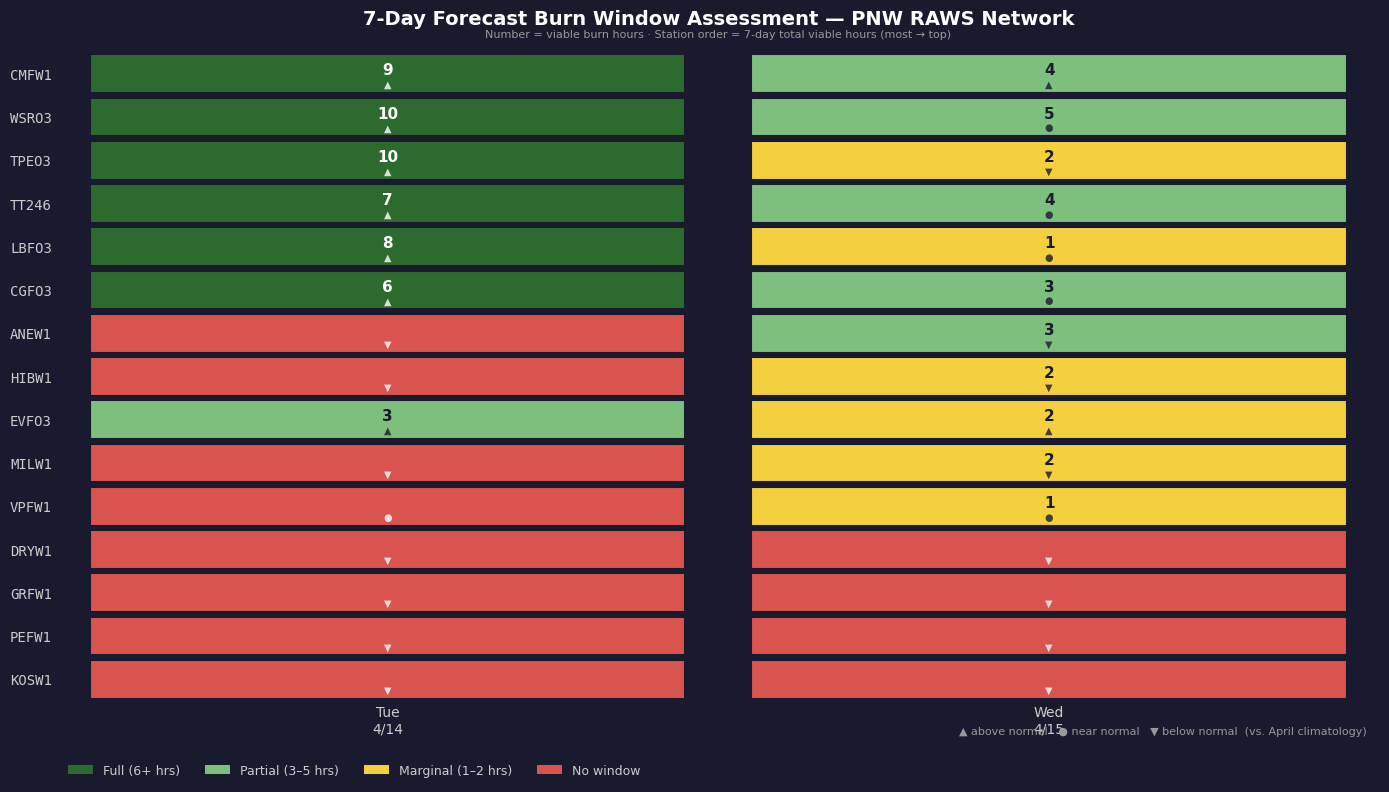

Saved → data/processed/ndfd/fig_forecast_window_table.png


In [6]:
# ── Color map ──────────────────────────────────────────────────────────────
QUALITY_COLORS = {
    "full":      "#2d6a2d",   # dark green
    "partial":   "#7dbf7d",   # medium green
    "marginal":  "#f4d03f",   # yellow
    "no_window": "#d9534f",   # red
}
QUALITY_ORDER = ["full", "partial", "marginal", "no_window"]

ANOMALY_MARKER = {
    "above_normal": "▲",
    "near_normal":  "●",
    "below_normal": "▼",
    "unknown":      " ",
}

# ── Pivot ──────────────────────────────────────────────────────────────────
plot_df = summary[summary["data_hours"] >= 4].copy()
plot_df["date_label"] = pd.to_datetime(plot_df["forecast_date"]).dt.strftime("%a\n%-m/%-d")

dates = sorted(plot_df["forecast_date"].unique())
# Drop partial first/last day if < 8 data hours
dates = [d for d in dates if plot_df[plot_df["forecast_date"] == d]["data_hours"].max() >= 8]

# Station order: sort by 7-day viable hours descending
station_order = (
    plot_df.groupby("station_id")["burn_window_hours"].sum()
    .sort_values(ascending=True)  # ascending for bottom-to-top on y-axis
    .index.tolist()
)

n_stations = len(station_order)
n_days = len(dates)

# ── Figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor("#1a1a2e")
ax.set_facecolor("#1a1a2e")

for row_idx, sid in enumerate(station_order):
    for col_idx, date in enumerate(dates):
        row = plot_df[(plot_df["station_id"] == sid) & (plot_df["forecast_date"] == date)]
        if row.empty:
            color = "#333355"
            hrs_text = ""
            anom = " "
        else:
            r = row.iloc[0]
            color = QUALITY_COLORS.get(r["window_quality"], "#333355")
            hrs_text = str(int(r["burn_window_hours"])) if r["burn_window_hours"] > 0 else ""
            anom = ANOMALY_MARKER.get(r["anomaly_label"], " ")

        rect = plt.Rectangle(
            (col_idx + 0.05, row_idx + 0.05), 0.9, 0.9,
            facecolor=color, edgecolor="#1a1a2e", linewidth=1.5
        )
        ax.add_patch(rect)

        # Hours annotation
        if hrs_text:
            ax.text(
                col_idx + 0.5, row_idx + 0.58, hrs_text,
                ha="center", va="center", fontsize=11, fontweight="bold",
                color="white" if color in (QUALITY_COLORS["full"], QUALITY_COLORS["no_window"]) else "#1a1a2e"
            )
        # Anomaly marker
        ax.text(
            col_idx + 0.5, row_idx + 0.25, anom,
            ha="center", va="center", fontsize=7,
            color="white" if color in (QUALITY_COLORS["full"], QUALITY_COLORS["no_window"]) else "#1a1a2e",
            alpha=0.8
        )

# ── Axes labels ────────────────────────────────────────────────────────────
ax.set_xlim(0, n_days)
ax.set_ylim(0, n_stations)

date_labels = [
    pd.to_datetime(d).strftime("%a\n%-m/%-d") for d in dates
]
ax.set_xticks([i + 0.5 for i in range(n_days)])
ax.set_xticklabels(date_labels, color="#cccccc", fontsize=10)
ax.set_yticks([i + 0.5 for i in range(n_stations)])
ax.set_yticklabels(station_order, color="#cccccc", fontsize=10, fontfamily="monospace")

ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# ── Legend ─────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor=QUALITY_COLORS["full"],      label="Full (6+ hrs)"),
    mpatches.Patch(facecolor=QUALITY_COLORS["partial"],   label="Partial (3–5 hrs)"),
    mpatches.Patch(facecolor=QUALITY_COLORS["marginal"],  label="Marginal (1–2 hrs)"),
    mpatches.Patch(facecolor=QUALITY_COLORS["no_window"], label="No window"),
]
legend = ax.legend(
    handles=legend_elements, loc="upper left",
    bbox_to_anchor=(0, -0.08), ncol=4,
    frameon=False, labelcolor="#cccccc", fontsize=9
)

# Anomaly note
ax.text(
    n_days - 0.02, -0.6,
    "▲ above normal   ● near normal   ▼ below normal  (vs. April climatology)",
    ha="right", va="top", fontsize=8, color="#999999"
)

# Number annotations = viable hrs that day
ax.text(
    n_days / 2, n_stations + 0.3,
    "Number = viable burn hours · Station order = 7-day total viable hours (most → top)",
    ha="center", va="bottom", fontsize=8, color="#999999"
)

ax.set_title(
    "7-Day Forecast Burn Window Assessment — PNW RAWS Network",
    color="white", fontsize=14, fontweight="bold", pad=20
)

plt.tight_layout()
out_path = Path("data/processed/ndfd/fig_forecast_window_table.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → {out_path}")

## 4. Visualization 2 — Anomaly chart

Forecast viable hours vs. climatological mean for this week, per station.
Sorted by anomaly magnitude. Error bars show the day-to-day spread across the 7-day window.

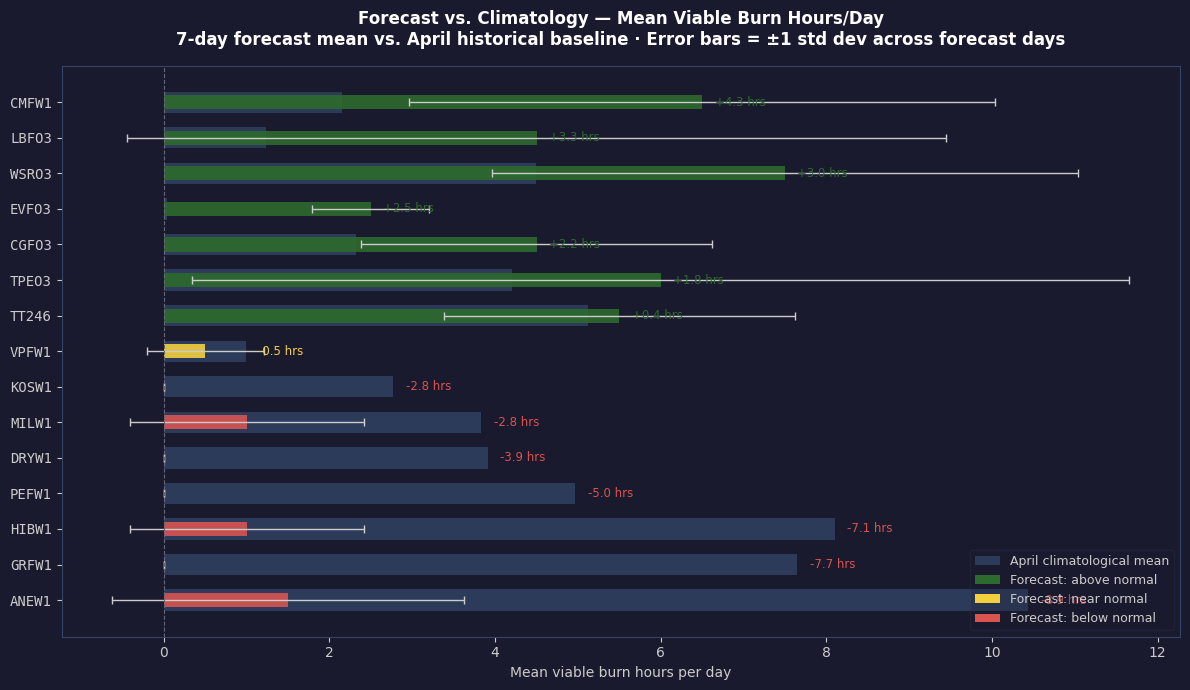

Saved → data/processed/ndfd/fig_forecast_anomaly.png


In [7]:
# Per-station aggregates for anomaly chart
anom_df = (
    full_days.groupby("station_id")
    .agg(
        forecast_mean_hrs=("burn_window_hours", "mean"),
        forecast_std_hrs=("burn_window_hours", "std"),
        climo_mean_hrs=("climo_mean_viable_hrs", "first"),
        climo_viable_pct=("climo_viable_day_pct", "first"),
        mean_anomaly=("anomaly_hrs", "mean"),
        anomaly_label=("anomaly_label", lambda x: x.mode().iloc[0]),
    )
    .reset_index()
    .sort_values("mean_anomaly")
)

ANOMALY_COLORS = {
    "above_normal": "#2d6a2d",
    "near_normal":  "#f4d03f",
    "below_normal": "#d9534f",
    "unknown":      "#666666",
}

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("#1a1a2e")
ax.set_facecolor("#1a1a2e")

y_pos = np.arange(len(anom_df))
bar_colors = [ANOMALY_COLORS[lbl] for lbl in anom_df["anomaly_label"]]

# Climatological baseline bars (background)
ax.barh(
    y_pos, anom_df["climo_mean_hrs"],
    height=0.6, color="#334466", alpha=0.8, label="Climatological mean (April)"
)

# Forecast bars
bars = ax.barh(
    y_pos, anom_df["forecast_mean_hrs"],
    height=0.4, color=bar_colors, alpha=0.9,
    xerr=anom_df["forecast_std_hrs"].fillna(0),
    error_kw={"ecolor": "#cccccc", "capsize": 3, "linewidth": 1},
    label="7-day forecast mean"
)

# Zero line
ax.axvline(0, color="#666677", linewidth=0.8, linestyle="--")

# Annotations — anomaly delta
for i, row in anom_df.iterrows():
    idx = list(anom_df.index).index(i)
    delta = row["mean_anomaly"]
    sign = "+" if delta > 0 else ""
    x_pos = max(row["forecast_mean_hrs"], row["climo_mean_hrs"]) + 0.15
    ax.text(
        x_pos, idx, f"{sign}{delta:.1f} hrs",
        va="center", ha="left", fontsize=8.5,
        color=ANOMALY_COLORS[row["anomaly_label"]]
    )

# Axes
ax.set_yticks(y_pos)
ax.set_yticklabels(anom_df["station_id"], color="#cccccc", fontsize=10, fontfamily="monospace")
ax.set_xlabel("Mean viable burn hours per day", color="#cccccc", fontsize=10)
ax.tick_params(colors="#cccccc")
ax.xaxis.label.set_color("#cccccc")
for spine in ax.spines.values():
    spine.set_color("#334466")

# Legend
legend_elements = [
    mpatches.Patch(facecolor="#334466", alpha=0.8, label="April climatological mean"),
    mpatches.Patch(facecolor="#2d6a2d", label="Forecast: above normal"),
    mpatches.Patch(facecolor="#f4d03f", label="Forecast: near normal"),
    mpatches.Patch(facecolor="#d9534f", label="Forecast: below normal"),
]
ax.legend(
    handles=legend_elements, loc="lower right",
    frameon=True, framealpha=0.2, labelcolor="#cccccc", fontsize=9,
    facecolor="#1a1a2e", edgecolor="#334466"
)

ax.set_title(
    "Forecast vs. Climatology — Mean Viable Burn Hours/Day\n"
    "7-day forecast mean vs. April historical baseline · Error bars = ±1 std dev across forecast days",
    color="white", fontsize=12, fontweight="bold", pad=15
)

plt.tight_layout()
out_path = Path("data/processed/ndfd/fig_forecast_anomaly.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → {out_path}")

## 5. Visualization 3 — Hourly RH and wind detail for top candidate stations

For stations with full or partial windows, show the raw hourly forecast
with threshold bands. Answers: *why* is this a window, and when exactly does it occur?

INFO | Threshold pass rate: 180 / 885 timesteps (20.3%)


Top 4 stations by 7-day viable hours: ['WSRO3', 'CMFW1', 'TPEO3', 'TT246']


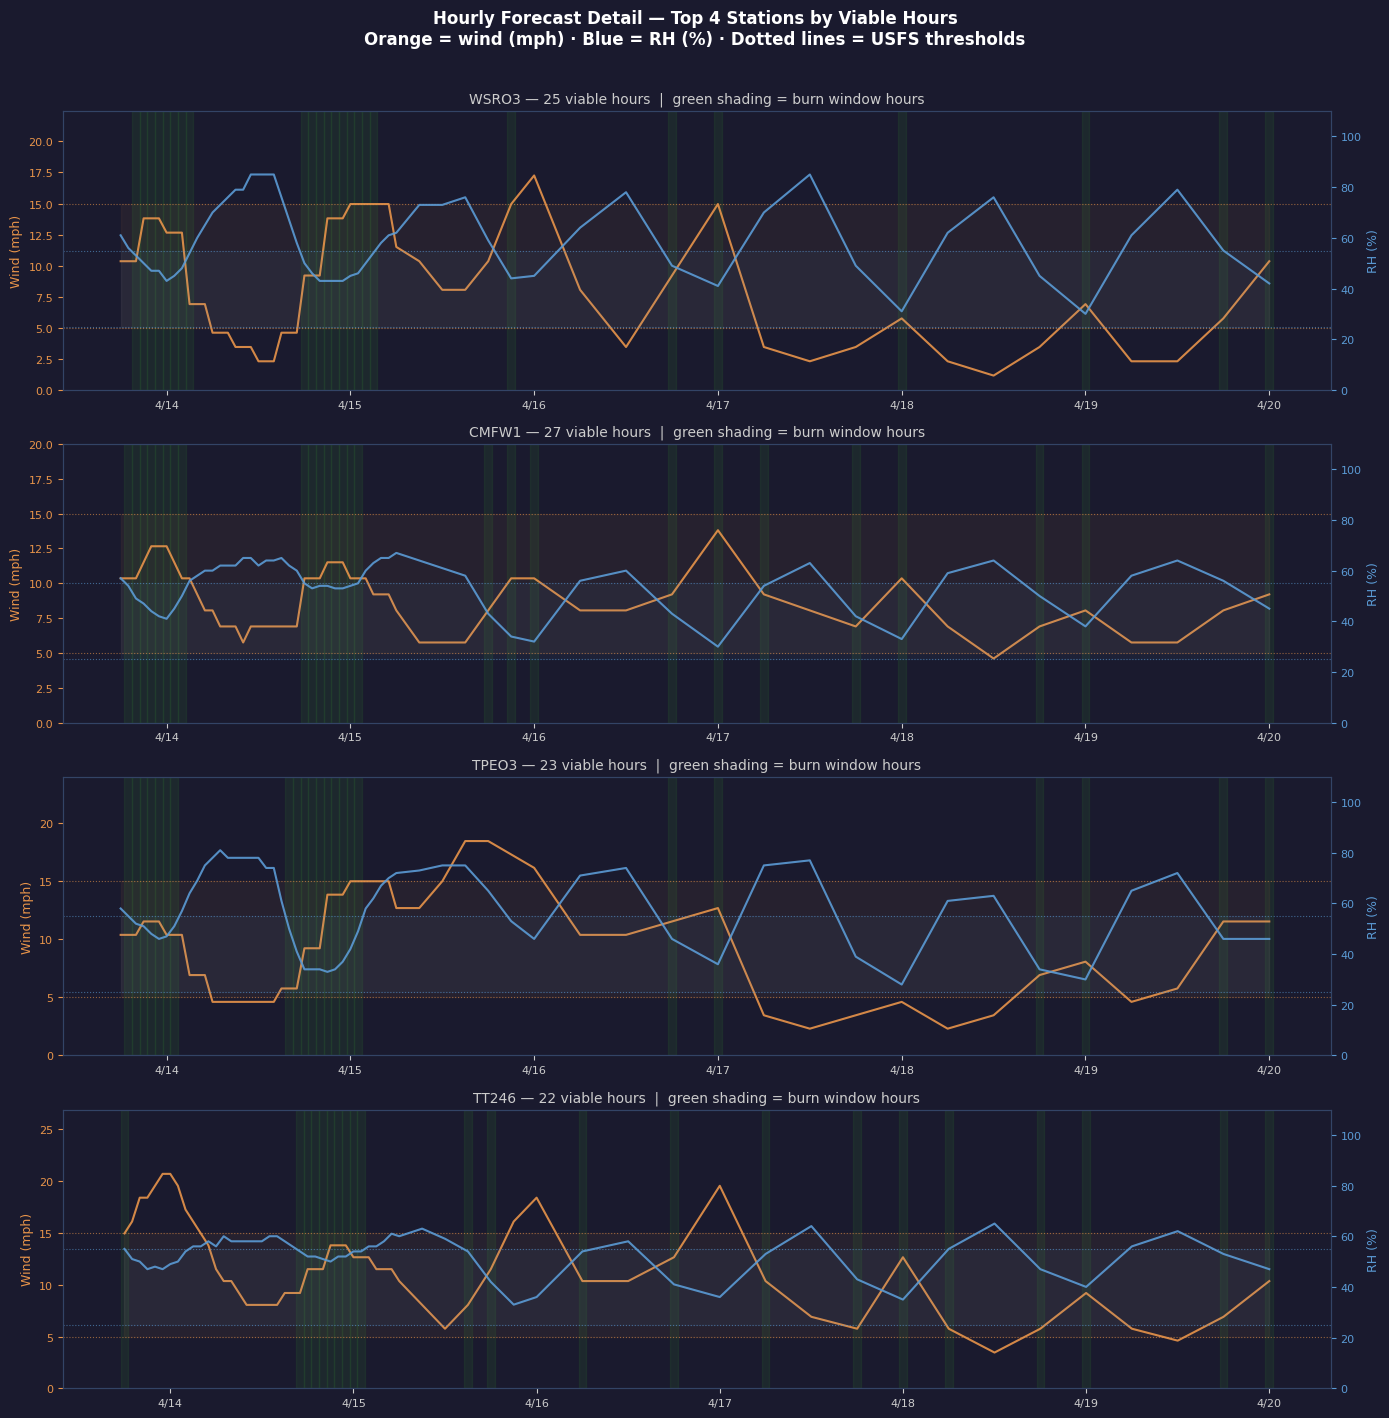

Saved → data/processed/ndfd/fig_hourly_detail.png


In [8]:
# Load raw hourly forecast to get time-of-day detail
forecast_raw = pd.read_csv(
    "data/processed/ndfd/forecast_parsed.csv",
    parse_dates=["valid_time"]
)

from src.analysis.forecast_windows import apply_thresholds_to_forecast, RH_MIN, RH_MAX, WIND_MIN, WIND_MAX
hourly = apply_thresholds_to_forecast(forecast_raw)

# Pick the 4 stations with the most forecast viable hours
top_stations = (
    summary[summary["data_hours"] >= 8]
    .groupby("station_id")["burn_window_hours"].sum()
    .nlargest(4).index.tolist()
)
print("Top 4 stations by 7-day viable hours:", top_stations)

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=False)
fig.patch.set_facecolor("#1a1a2e")

for ax, sid in zip(axes, top_stations):
    ax.set_facecolor("#1a1a2e")
    df = hourly[hourly["station_id"] == sid].copy().sort_values("valid_time")

    x = df["valid_time"]

    # Shade burn window hours
    for _, row in df.iterrows():
        if row["burn_window"]:
            ax.axvspan(
                row["valid_time"] - pd.Timedelta(minutes=30),
                row["valid_time"] + pd.Timedelta(minutes=30),
                alpha=0.18, color="#2d6a2d", zorder=0
            )

    # RH line and thresholds
    ax2 = ax.twinx()
    ax2.set_facecolor("#1a1a2e")
    ax2.plot(x, df["rh_forecast"], color="#5b9bd5", linewidth=1.5, label="RH (%)", alpha=0.9)
    ax2.axhline(RH_MIN, color="#5b9bd5", linewidth=0.8, linestyle=":", alpha=0.6)
    ax2.axhline(RH_MAX, color="#5b9bd5", linewidth=0.8, linestyle=":", alpha=0.6)
    ax2.fill_between(x, RH_MIN, RH_MAX, alpha=0.06, color="#5b9bd5")
    ax2.set_ylabel("RH (%)", color="#5b9bd5", fontsize=9)
    ax2.tick_params(axis="y", colors="#5b9bd5", labelsize=8)
    ax2.set_ylim(0, 110)

    # Wind line and thresholds
    ax.plot(x, df["wind_mph_forecast"], color="#e8944a", linewidth=1.5, label="Wind (mph)", alpha=0.9)
    ax.axhline(WIND_MIN, color="#e8944a", linewidth=0.8, linestyle=":", alpha=0.6)
    ax.axhline(WIND_MAX, color="#e8944a", linewidth=0.8, linestyle=":", alpha=0.6)
    ax.fill_between(x, WIND_MIN, WIND_MAX, alpha=0.06, color="#e8944a")
    ax.set_ylabel("Wind (mph)", color="#e8944a", fontsize=9)
    ax.tick_params(axis="y", colors="#e8944a", labelsize=8)
    ax.tick_params(axis="x", colors="#cccccc", labelsize=8)
    ax.set_ylim(0, max(df["wind_mph_forecast"].max() * 1.3, WIND_MAX + 5))

    for spine in ax.spines.values():
        spine.set_color("#334466")
    for spine in ax2.spines.values():
        spine.set_color("#334466")

    # Viable hours count for this station
    viable_hrs = df["burn_window"].sum()
    ax.set_title(f"{sid} — {viable_hrs} viable hours  |  green shading = burn window hours",
                 color="#cccccc", fontsize=10, pad=6)

    # X-axis: date labels at midnight
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%-m/%-d"))

fig.suptitle(
    "Hourly Forecast Detail — Top 4 Stations by Viable Hours\n"
    "Orange = wind (mph) · Blue = RH (%) · Dotted lines = USFS thresholds",
    color="white", fontsize=12, fontweight="bold", y=1.01
)

plt.tight_layout()
out_path = Path("data/processed/ndfd/fig_hourly_detail.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → {out_path}")

## 6. Findings summary

Auto-generated from the computed tables.

In [9]:
from datetime import datetime

# Stations with full windows
full_window_stations = (
    full_days[full_days["window_quality"] == "full"]
    .groupby("station_id")["burn_window_hours"].sum()
    .sort_values(ascending=False)
)

# Stations with zero windows
zero_stations = station_summary[station_summary["any_window_days"] == 0]["station_id"].tolist()

# Above-normal stations
above_normal = anom_df[anom_df["anomaly_label"] == "above_normal"]["station_id"].tolist()
below_normal = anom_df[anom_df["anomaly_label"] == "below_normal"]["station_id"].tolist()

# Dominant limiting factor across no-window days
limit_counts = (
    full_days[full_days["any_window"] == False]["limiting_factor"]
    .value_counts()
)

forecast_start = pd.to_datetime(summary["forecast_date"].min()).strftime("%B %-d")
forecast_end   = pd.to_datetime(summary["forecast_date"].max()).strftime("%B %-d, %Y")

print("=" * 72)
print(f"FORECAST BURN WINDOW SUMMARY — {forecast_start}–{forecast_end}")
print("=" * 72)
print()
print(f"NETWORK OVERVIEW")
print(f"  Stations assessed:         {summary['station_id'].nunique()}")
print(f"  With any viable window:    {(station_summary['any_window_days'] > 0).sum()}")
print(f"  With full window (6+ hrs): {(station_summary['full_window_days'] > 0).sum()}")
print(f"  With zero viable windows:  {len(zero_stations)}")
print()

if len(full_window_stations) > 0:
    print("FULL WINDOW STATIONS (≥6 viable hrs on at least one day):")
    for sid, hrs in full_window_stations.items():
        best_day = full_days[(full_days["station_id"] == sid) & (full_days["window_quality"] == "full")]
        best_date = pd.to_datetime(best_day.loc[best_day["burn_window_hours"].idxmax(), "forecast_date"]).strftime("%a %-m/%-d")
        print(f"  {sid:8s}  {hrs:3.0f} total hrs  |  best day: {best_date}")
    print()

print("CLIMATOLOGICAL CONTEXT:")
if above_normal:
    print(f"  Above normal:  {', '.join(above_normal)}")
    print(f"     → Forecast exceeds April historical mean — opportunistic windows")
if below_normal:
    print(f"  Below normal:  {', '.join(below_normal[:6])}{'...' if len(below_normal) > 6 else ''}")
    print(f"     → RH running wet this week relative to April climatology")
print()

if len(limit_counts) > 0:
    top_limit = limit_counts.index[0]
    print("PRIMARY LIMITING FACTOR (no-window days):")
    for factor, count in limit_counts.head(3).items():
        print(f"  {factor:20s}  {count} station-days")
    print()

if zero_stations:
    print(f"NO VIABLE WINDOWS THIS WEEK: {', '.join(zero_stations)}")
    print(f"  These stations should not be prioritized for burn planning this period.")
print()
print("NOTE: Temperature threshold (< 90°F) assumed satisfied — NDFD does not")
print("  serve temperature for this product. PNW April climatology supports this.")
print("=" * 72)

FORECAST BURN WINDOW SUMMARY — April 13–April 20, 2026

NETWORK OVERVIEW
  Stations assessed:         15
  With any viable window:    11
  With full window (6+ hrs): 6
  With zero viable windows:  4

FULL WINDOW STATIONS (≥6 viable hrs on at least one day):
  WSRO3      10 total hrs  |  best day: Tue 4/14
  TPEO3      10 total hrs  |  best day: Tue 4/14
  CMFW1       9 total hrs  |  best day: Tue 4/14
  LBFO3       8 total hrs  |  best day: Tue 4/14
  TT246       7 total hrs  |  best day: Tue 4/14
  CGFO3       6 total hrs  |  best day: Tue 4/14

CLIMATOLOGICAL CONTEXT:
  Above normal:  TT246, TPEO3, CGFO3, EVFO3, WSRO3, LBFO3, CMFW1
     → Forecast exceeds April historical mean — opportunistic windows
  Below normal:  ANEW1, GRFW1, HIBW1, PEFW1, DRYW1, MILW1...
     → RH running wet this week relative to April climatology

PRIMARY LIMITING FACTOR (no-window days):
  rh_too_wet            11 station-days
  wind_too_strong       1 station-days

NO VIABLE WINDOWS THIS WEEK: GRFW1, DRYW1,

## 7. Save outputs

All figures and the summary CSV are written to `data/processed/ndfd/`.

In [10]:
output_dir = Path("data/processed/ndfd")
print("Week 3 outputs:")
for f in sorted(output_dir.glob("*")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:50s}  {size_kb:6.1f} KB")

Week 3 outputs:
  .gitkeep                                               0.0 KB
  fig_forecast_anomaly.png                             109.2 KB
  fig_forecast_window_table.png                         99.6 KB
  fig_hourly_detail.png                                449.6 KB
  forecast_parsed.csv                                   69.2 KB
  forecast_parsed_20260413.csv                          69.2 KB
  forecast_summary.csv                                  15.0 KB
